# LeetCode #1231: Divide Chocolate

https://leetcode.com/problems/divide-chocolate/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (try all splits)** | $O(\binom{n}{k} \cdot n)$ | $O(k)$ |
| **Optimal: Binary Search on Minimum Sweetness ★** | $O(n \log(\text{sum}))$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (try all splits)
Enumerate all $\binom{n-1}{k}$ ways to cut the bar into $k+1$ pieces, compute the minimum piece sweetness for each split, and return the maximum. Exponential in $k$ — infeasible for $k$ up to $n-1$.

### Optimal: Binary Search on Minimum Sweetness ★
Binary search the answer in $[\min(\text{sweetness}), \text{sum} / (k+1)]$. For a candidate minimum $m$, greedily cut: accumulate sweetness until reaching $m$, then make a cut. If we can make at least $k+1$ cuts, $m$ is achievable. Monotone feasibility lets us binary-search with $O(n)$ per check → $O(n \log(\text{sum}))$ total.

**Why this is better than Brute Force:** Binary search on the answer value replaces exponential enumeration with a logarithmic search over $[1, \text{sum}]$.

**Constraints:**
* $1 \le k < \text{sweetness.length} \le 10^4$
* $1 \le \text{sweetness}[i] \le 10^5$


## Solutions

### C#

In [ ]:
public int MaximizeSweetness(int[] sweetness, int k) {
    int lo = sweetness.Min(), hi = sweetness.Sum() / (k + 1);
    while (lo < hi) {
        int mid = lo + (hi - lo + 1) / 2;
        // Greedily count pieces with sweetness >= mid
        int pieces = 0, cur = 0;
        foreach (int s in sweetness) {
            cur += s;
            if (cur >= mid) { pieces++; cur = 0; }
        }
        // If we can give everyone a piece, mid is achievable
        if (pieces >= k + 1) lo = mid;
        else hi = mid - 1;
    }
    return lo;
}


### Python

In [ ]:
def maximize_sweetness(sweetness: list[int], k: int) -> int:
    lo, hi = min(sweetness), sum(sweetness) // (k + 1)
    while lo < hi:
        mid = lo + (hi - lo + 1) // 2
        # Greedily count pieces with sweetness >= mid
        pieces = cur = 0
        for s in sweetness:
            cur += s
            if cur >= mid:
                pieces += 1
                cur = 0
        # If we can give everyone a piece, mid is achievable
        if pieces >= k + 1:
            lo = mid
        else:
            hi = mid - 1
    return lo


### Go

In [ ]:
func maximizeSweetness(sweetness []int, k int) int {
    lo, hi := slices.Min(sweetness), 0
    for _, s := range sweetness { hi += s }
    hi /= (k + 1)
    for lo < hi {
        mid := lo + (hi-lo+1)/2
        // Greedily count pieces with sweetness >= mid
        pieces, cur := 0, 0
        for _, s := range sweetness {
            cur += s
            if cur >= mid { pieces++; cur = 0 }
        }
        // If we can give everyone a piece, mid is achievable
        if pieces >= k+1 { lo = mid } else { hi = mid - 1 }
    }
    return lo
}


### Rust

In [ ]:
pub fn maximize_sweetness(sweetness: Vec<i32>, k: i32) -> i32 {
    let (mut lo, mut hi) = (
        *sweetness.iter().min().unwrap(),
        sweetness.iter().sum::<i32>() / (k + 1),
    );
    while lo < hi {
        let mid = lo + (hi - lo + 1) / 2;
        // Greedily count pieces with sweetness >= mid
        let (mut pieces, mut cur) = (0i32, 0i32);
        for &s in &sweetness {
            cur += s;
            if cur >= mid { pieces += 1; cur = 0; }
        }
        // If we can give everyone a piece, mid is achievable
        if pieces >= k + 1 { lo = mid; } else { hi = mid - 1; }
    }
    lo
}


## Example Scenarios

**1. Common Case**
**Input:** sweetness = [1, 2, 3, 4, 5, 6, 7, 8, 9], k = 5
lo=1, hi=45/6=7. mid=4: greedily [1+2+3=6≥4✓, 4≥4✓, 5≥4✓, 6≥4✓, 7≥4✓, 8≥4✓, 9≥4✓] → 7 pieces ≥ 6 → lo=4. mid=6: [1+2+3+4+5=15: cut at 15? No — stops at 1+2+3+4=10≥6✓, then 5+6=11≥6✓, then 7≥6✓, 8≥6✓, 9≥6✓] → 5 pieces < 6 → hi=5. Answer: 6.

**2. Slightly Complex**
**Input:** sweetness = [5, 5, 5, 5], k = 2
lo=5, hi=20/3=6. mid=6: greedy: 5<6, 5+5=10≥6✓, 5+5=10≥6✓ → 2 pieces < 3=k+1 → hi=5. lo=hi=5. Three people each get at least 5 sweetness.

**3. Edge Case: Time Factor**
**Input:** sweetness = [1, 1, ..., 1] (10000 ones), k = 9999 (must cut into 10000 pieces of size 1)
lo=1, hi=10000/10000=1. Already lo=hi=1 → done in 0 iterations. The greedy check would confirm 10000 pieces of 1 each.

**4. Edge Case: Space Factor**
**Input:** sweetness = [100000, 100000, ..., 100000] (10000 elements), k = 1
lo=100000, hi=10^9/2=500000000? No: hi=sum/(k+1)=10^9/2=5×10^8. Binary search: lo=100000, hi=5×10^8. Only 5 variables used (lo, hi, mid, pieces, cur). $O(1)$ space.

**5. Almost-Impossible but Plausible**
**Input:** sweetness = [1, 100000, 1, 100000], k = 1 (give 2 pieces to 2 people)
sum=200002, hi=100001. Greedy at mid=100001: [1<100001, 1+100000=100001≥100001✓, 1<100001, 1+100000=100001≥100001✓] → 2 pieces = k+1 → lo=100001. Answer: 100001. Cutting after positions 1 and 3 gives both pieces exactly 100001.


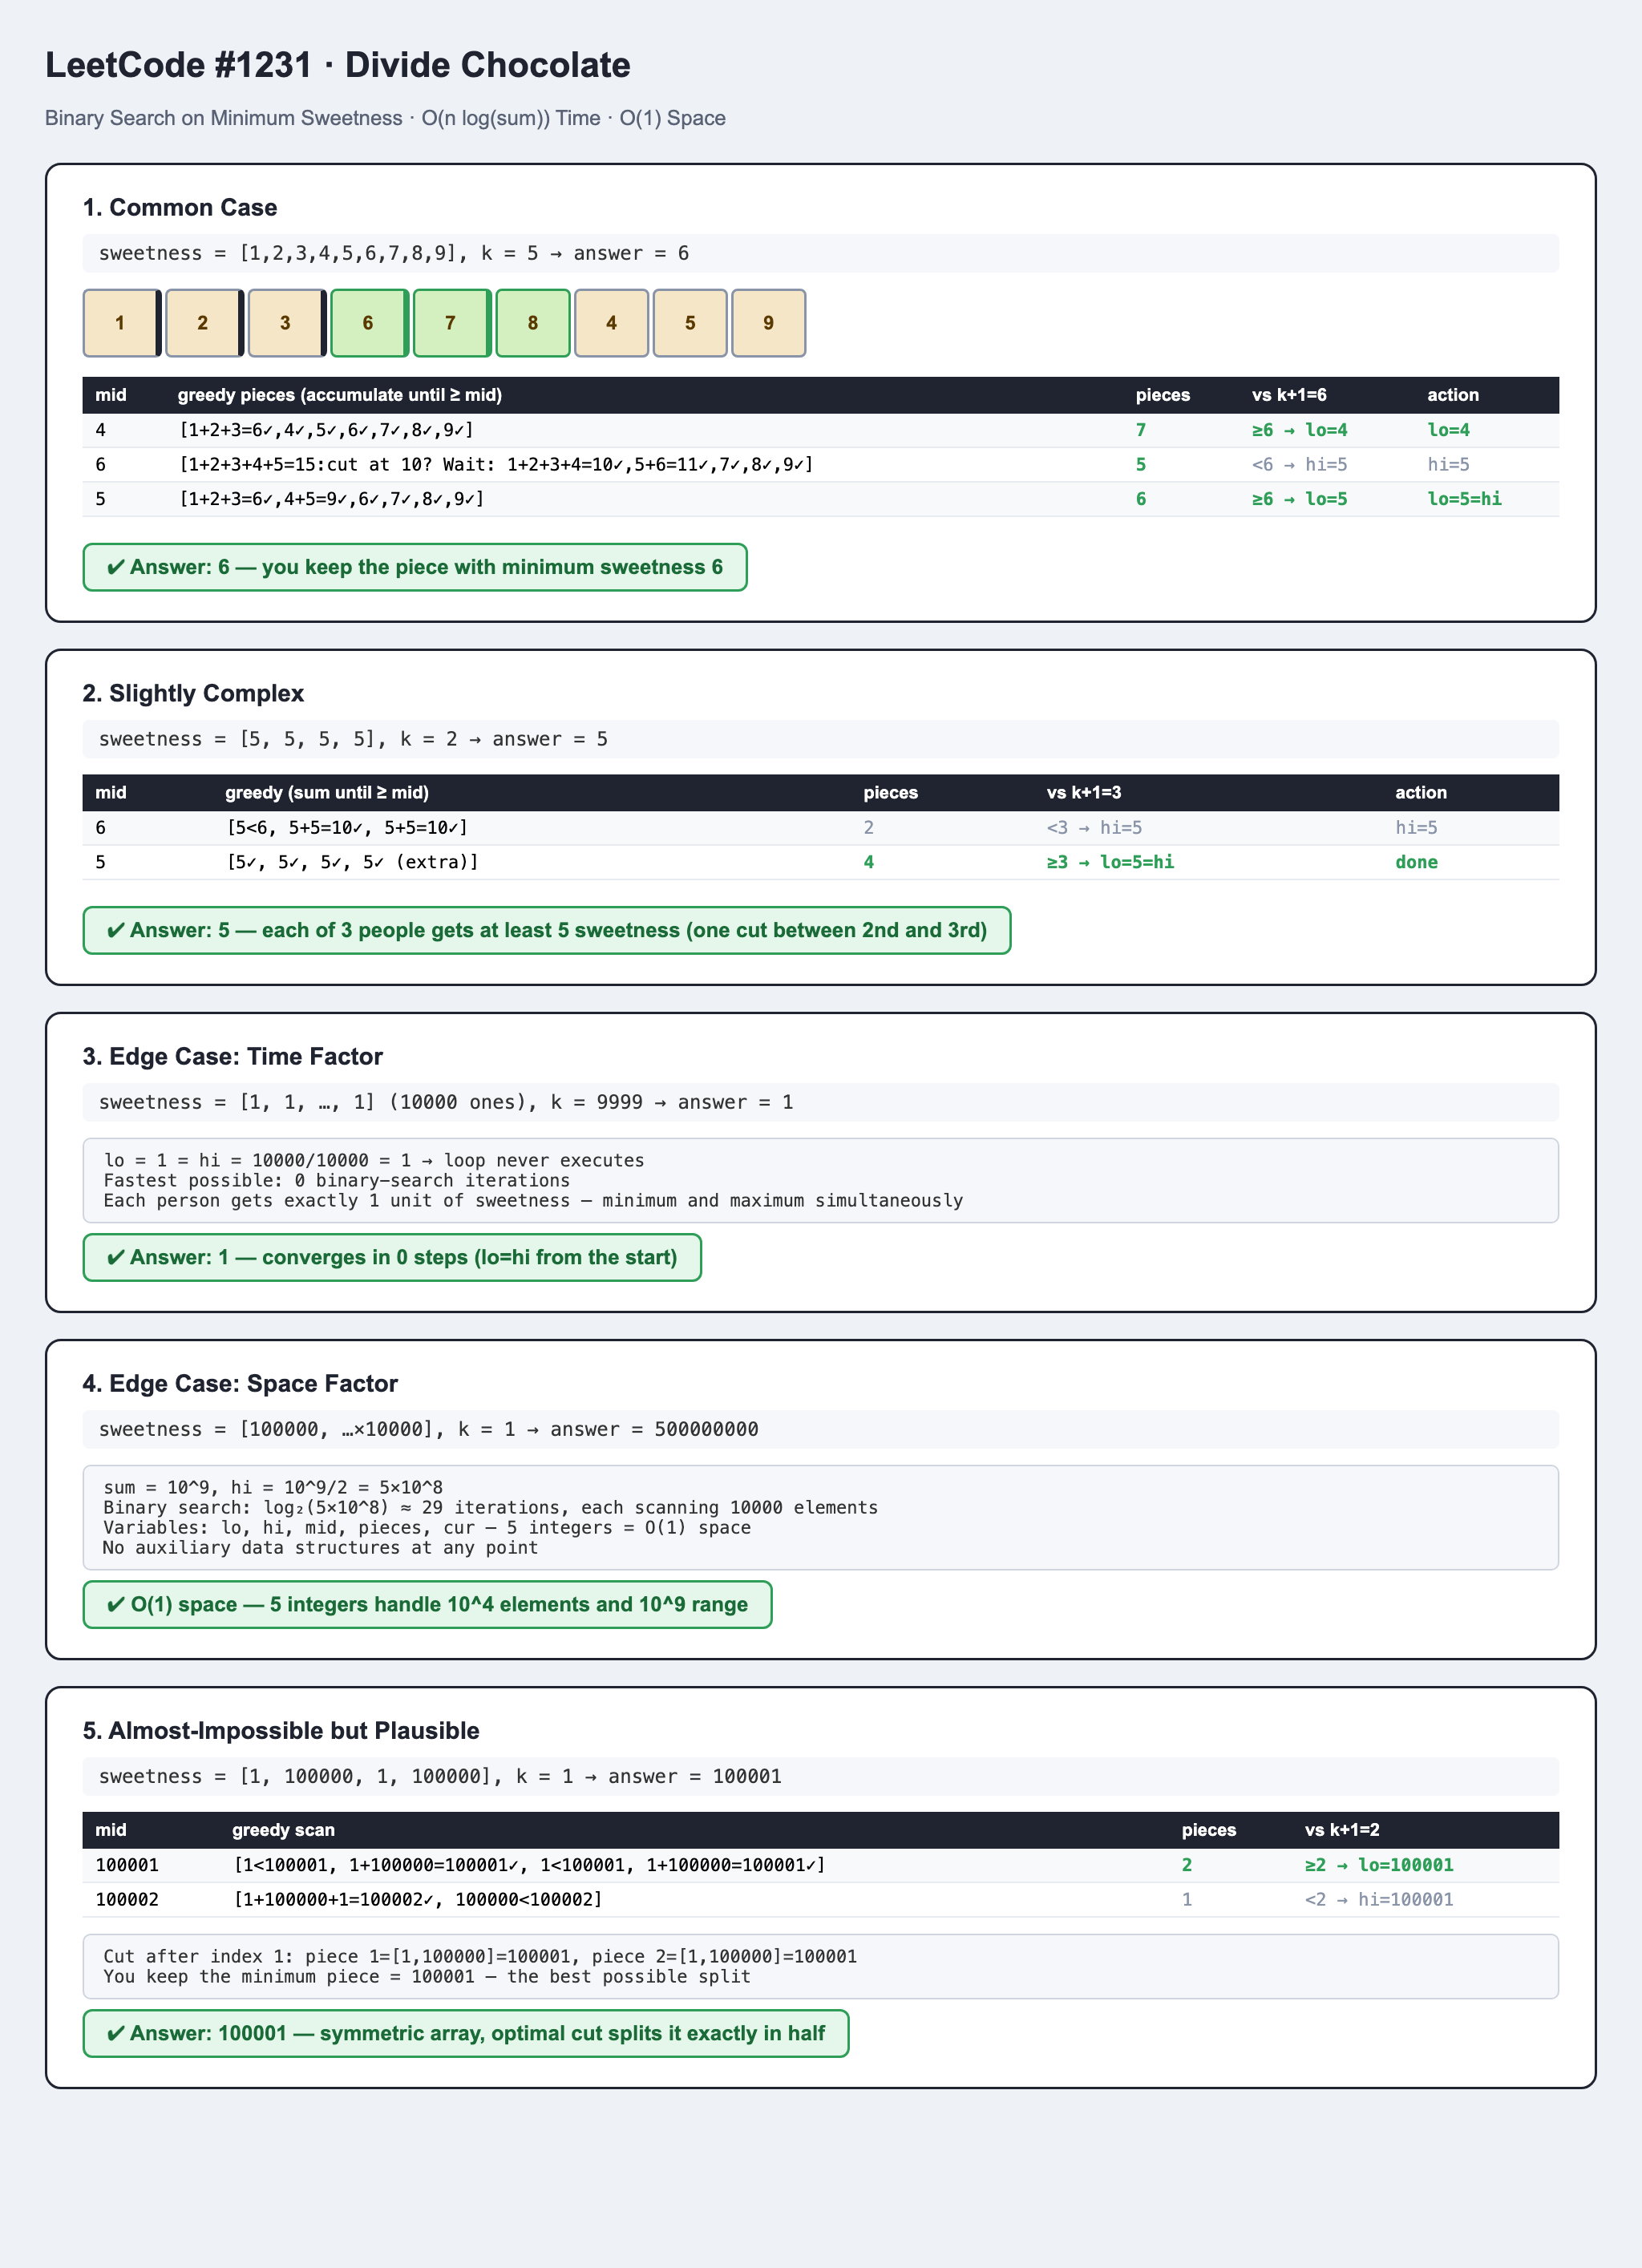